# Session 5 — Quantitative representations of the data

Figures support a conclusion, so the chain of logic should be **data → interpretation → representation**, not interpretation → data → representation. This notebook is about choosing scales, showing distributions honestly, using color consistently, and preparing the extension and presentation.

**Topics** (from the Session 5 slides):
1. Review of Session 4 (team discussion).
2. Appropriate choice of scale.
3. Displaying and interpreting distributions.
4. Color across related plots.
5. Sensitivity to filtering, shown across sites.
6. Choosing an extension question and preparing the presentation.

**For each analysis, be ready to explain:** what you did, how the code works, and how you checked it.

## 0. Setup

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#allow multiple outputs per cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

### Functions
Copied from Session 4 (their contracts and tests are in Sessions 3 and 4). If you change one here, change it there too.

In [22]:
# 3-letter amino acid code -> 1-letter code
letter = {"Ala": "A", "Arg": "R", "Asn": "N", "Asp": "D", "Cys": "C", "Gln": "Q", "Glu": "E", "Gly": "G",
          "His": "H", "Ile": "I", "Leu": "L", "Lys": "K", "Met": "M", "Phe": "F", "Pro": "P", "Ser": "S",
          "Thr": "T", "Trp": "W", "Tyr": "Y", "Val": "V"}


def read_fasta(path):
    """Return the protein sequence in a FASTA file as one string."""
    lines = path.read_text().splitlines()
    return "".join(line.strip() for line in lines if not line.startswith(">"))


def get_checked_missense(table, ref_seq):
    """Return the missense rows of table, with new columns wt, pos, and mut.

    Raises ValueError if a label cannot be parsed, is not a real substitution,
    sits outside the protein, has a WT residue that does not match ref_seq, or
    is duplicated. Missing scores are kept as NaN.
    """
    df = table[table["record_type"] == "missense"].copy()

    # "p.His75Asp" -> wt "His", site 75, mutant "Asp"
    parts = df["hgvs_pro"].str.extract(r"^p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})$")
    if parts[0].isna().any():
        raise ValueError("unparseable label(s): " + str(df.loc[parts[0].isna(), "hgvs_pro"].tolist()[:5]))
    df["wt"], df["pos"], df["mut"] = parts[0], parts[1].astype(int), parts[2]

    if not df["mut"].isin(list(letter)).all() or (df["mut"] == df["wt"]).any():
        raise ValueError("not a missense substitution")
    if not df["pos"].between(1, len(ref_seq)).all():
        raise ValueError("site outside the protein")

    # sites count from 1, so label the reference letters 1, 2, 3, ...
    ref_by_site = pd.Series(list(ref_seq), index=range(1, len(ref_seq) + 1))
    if (df["wt"].map(letter) != df["pos"].map(ref_by_site)).any():
        raise ValueError("WT residue does not match the reference")
    if df["hgvs_pro"].duplicated().any():
        raise ValueError("duplicate labels")

    df["score"] = pd.to_numeric(df["score"])
    return df[["hgvs_pro", "wt", "pos", "mut", "score", "expts"]]


def site_stats(missense, n_sites, minimum_variants=5):
    """Score statistics for each site 1..n_sites.

    n_variants counts the variants with a score (0 where there are none).
    The statistics are NaN, never 0, where n_variants < minimum_variants.
    """
    scored = missense.dropna(subset=["score"])
    stats = scored.groupby("pos")["score"].agg(["count", "mean", "median", "std", "min", "max"])
    stats = stats.reindex(range(1, n_sites + 1))
    stats["count"] = stats["count"].fillna(0).astype(int)
    stats.loc[stats["count"] < minimum_variants, ["mean", "median", "std", "min", "max"]] = np.nan
    return stats.rename(columns={"count": "n_variants"})


def make_site_region(regions, n_sites):
    """Region name for each site 1..n_sites; sites in no annotated region are "unannotated"."""
    site_region = pd.Series("unannotated", index=range(1, n_sites + 1))
    for _, r in regions.iterrows():
        site_region.loc[r["start"]:r["end"]] = r["region"]   # .loc includes both ends
    return site_region


def region_summary(missense, site_region, minimum_variants=5, minimum_experiments=1):
    """Summarize each region after filtering variants (expts) and then sites (number of variants).

    Returns (summary, included, site_table):
      summary    one row per region: included_variants, included_sites, total_sites,
                 variant_median (median of all included variants), site_median (median of site medians)
      included   the variants that passed both filters, with a region column
      site_table the included sites, with their statistics and region
    """
    kept = missense[missense["expts"] >= minimum_experiments]
    site_table = site_stats(kept, len(site_region), minimum_variants)
    site_table["region"] = site_region
    site_table = site_table[site_table["n_variants"] >= minimum_variants]

    included = kept[kept["pos"].isin(site_table.index)].copy()
    included["region"] = included["pos"].map(site_region)

    summary = pd.DataFrame({
        "included_variants": included.groupby("region").size(),
        "included_sites": site_table.groupby("region").size(),
        "total_sites": site_region.value_counts(),
        "variant_median": included.groupby("region")["score"].median(),
        "site_median": site_table.groupby("region")["median"].median(),
    }).reindex(list(site_region.unique()))
    summary[["included_variants", "included_sites"]] = summary[["included_variants", "included_sites"]].fillna(0).astype(int)
    return summary, included, site_table

Locate the data. This notebook assumes Jupyter is running with its working directory set to this notebook's folder (`code/my_code`), so the project root is two levels up. If a path check prints `False`, check `Path.cwd()`.

In [23]:
project_root = Path.cwd().parent.parent
data_dir = project_root / "data" / "raw_data"

abundance_path = data_dir / "derived" / "pten-variant-abundance.csv"
regions_path = data_dir / "derived" / "pten-region-annotations.csv"
fasta_path = data_dir / "derived" / "pten-reference-protein.fasta"

abundance_path.exists(), regions_path.exists(), fasta_path.exists()

(True, True, True)

In [24]:
abundance = pd.read_csv(abundance_path)
regions = pd.read_csv(regions_path)
ref_seq = read_fasta(fasta_path)
n_sites = len(ref_seq)

minimum_variants = 5
minimum_experiments = 1   # 1 = no filter on expts

missense = get_checked_missense(abundance, ref_seq)
site_region = make_site_region(regions, n_sites)
summary, included, site_table = region_summary(missense, site_region, minimum_variants, minimum_experiments)
region_order = list(site_region.unique())
summary

,included_variants,included_sites,total_sites,variant_median,site_median
unannotated,179,14,18,0.922347,0.909709
phosphatase_domain,1803,142,172,0.719033,0.722059
c2_domain,1502,120,161,0.731381,0.751647
disordered_tail,521,41,52,0.922675,0.941643


In [27]:
display(summary)

display("included\n", included)

display(region_order)

,included_variants,included_sites,total_sites,variant_median,site_median
unannotated,179,14,18,0.922347,0.909709
phosphatase_domain,1803,142,172,0.719033,0.722059
c2_domain,1502,120,161,0.731381,0.751647
disordered_tail,521,41,52,0.922675,0.941643


'included\n'

,hgvs_pro,wt,pos,mut,score,expts,region
1,p.Thr2Ser,Thr,2,Ser,0.824359,7.0,unannotated
2,p.Asn12Ile,Asn,12,Ile,0.298717,7.0,unannotated
3,p.Arg74Val,Arg,74,Val,0.855027,6.0,phosphatase_domain
4,p.His75Ala,His,75,Ala,0.863776,8.0,phosphatase_domain
5,p.His75Asp,His,75,Asp,1.045655,4.0,phosphatase_domain
...,...,...,...,...,...,...,...
4403,p.Arg74Leu,Arg,74,Leu,0.657145,6.0,phosphatase_domain
4404,p.Arg74Asn,Arg,74,Asn,1.158127,2.0,phosphatase_domain
4405,p.Arg74Pro,Arg,74,Pro,1.059395,2.0,phosphatase_domain
4407,p.Arg74Ser,Arg,74,Ser,0.868741,5.0,phosphatase_domain


['unannotated', 'phosphatase_domain', 'c2_domain', 'disordered_tail']

## 1. Review of Session 4 (team discussion)

Be ready to answer, and to describe your code clearly:
- How did you assign each PTEN variant to a region?
- How did you summarize the number of variants, included sites, and total sites in each region? How do these compare across regions?
- How did you compute the median scores (across variants, and across the median score of each included site) for each region, and how do you interpret them?
- How did you visualize and interpret score distributions across regions?
- What variables did you change to test the sensitivity of the results, and how did these changes affect the conclusions?

*Notes:*

## 2. Choosing the scale

Axis limits change visual contrast, so ask which scale is most relevant, and keep the context. Linear differences and log ratios answer different questions, so ask what the natural scale of the data is. Some missense scores are below 0, so think about what that means before taking a log. Missing data and zeros should look different.

Prompts:
- Plot the same scores with the default axis limits and with limits that show the full natural range. Which impression is the most faithful?
- Would a linear difference from WT or a log ratio fit abundance scores better? Why or why not?
- How can your plot show that a site has *no* data, as opposed to a score of zero?

<Axes: xlabel='region', ylabel='score'>

<Axes: xlabel='region', ylabel='score'>

[(0.6, 1.2),
 Text(0.5, 1.0, 'Zoomed in on WT-like scores'),
 Text(0.5, 0, ''),
 Text(0, 0.5, 'abundance score (WT = 1)')]

<Axes: xlabel='region', ylabel='score'>

<Axes: xlabel='region', ylabel='score'>

[(-0.3, 1.5),
 Text(0.5, 1.0, 'Full natural range'),
 Text(0.5, 0, ''),
 Text(0, 0.5, 'abundance score (WT = 1)')]

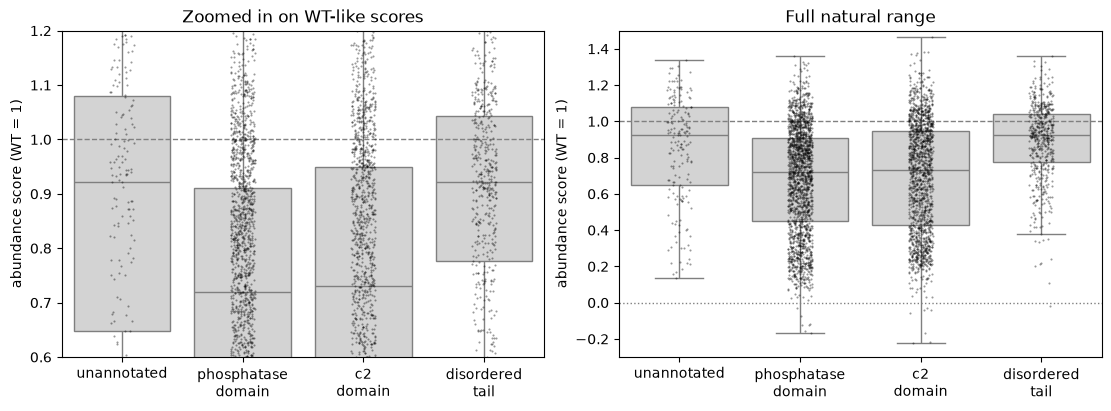

(0.6, 1.2) hides 1423 of 4005 variants
(-0.3, 1.5) hides 0 of 4005 variants


In [26]:
# Same data, two sets of axis limits
region_labels = [r.replace("_", "\n") for r in region_order]   # wrapped so the tick labels fit

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, limits, title in zip(axes, [(0.6, 1.2), (-0.3, 1.5)], ["Zoomed in on WT-like scores", "Full natural range"]):
    sns.boxplot(data=included, x="region", y="score", order=region_order, color="lightgray", fliersize=0, ax=ax)
    sns.stripplot(data=included, x="region", y="score", order=region_order, size=1.5, alpha=0.4, color="black", ax=ax)
    ax.axhline(1, ls="--", color="gray", lw=1)   # WT
    ax.axhline(0, ls=":", color="gray", lw=1)    # nonsense-like
    ax.set(ylim=limits, title=title, xlabel="", ylabel="abundance score (WT = 1)")
    ax.set_xticks(range(len(region_order)), region_labels)
plt.show()

# Check: how many variants does each view cut off?
for limits in [(0.6, 1.2), (-0.3, 1.5)]:
    outside = ~included["score"].between(*limits)
    print(limits, "hides", outside.sum(), "of", len(included), "variants")

15 of 4005 scores are <= 0, so their log ratio to WT does not exist


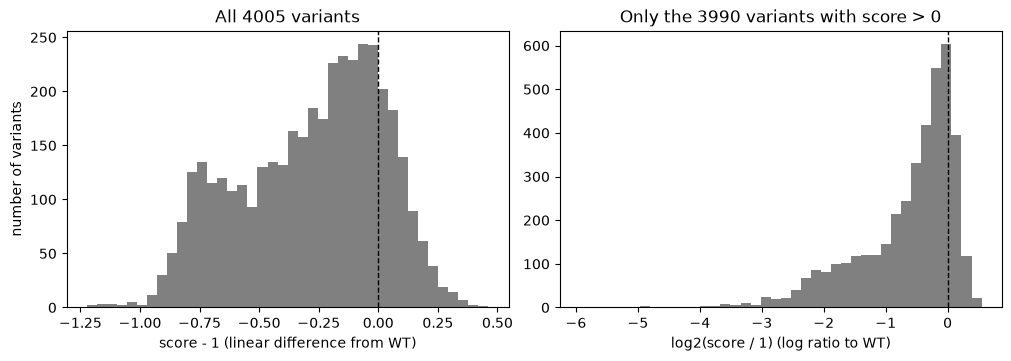

In [6]:
# Linear scale versus a log-based scale
n_not_positive = (included["score"] <= 0).sum()
print(n_not_positive, "of", len(included), "scores are <= 0, so their log ratio to WT does not exist")

positive = included[included["score"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
axes[0].hist(included["score"] - 1, bins=40, color="gray")
axes[0].set(xlabel="score - 1 (linear difference from WT)", ylabel="number of variants",
            title=f"All {len(included)} variants")
axes[1].hist(np.log2(positive["score"]), bins=40, color="gray")
axes[1].set(xlabel="log2(score / 1) (log ratio to WT)", title=f"Only the {len(positive)} variants with score > 0")
for ax in axes:
    ax.axvline(0, ls="--", color="black", lw=1)   # 0 = same as WT in both views
plt.show()

86 sites have no median; 0 have a median of exactly 0


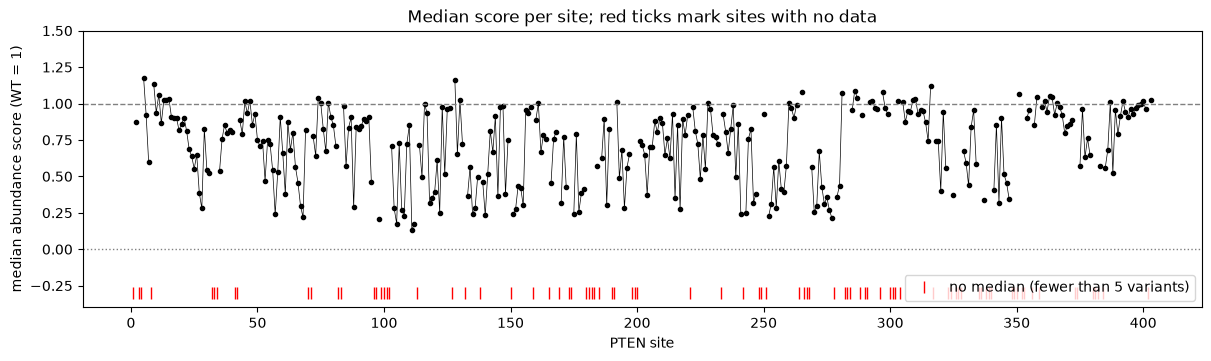

In [7]:
# Showing missing data differently from zeros
all_sites = site_stats(missense, n_sites, minimum_variants)   # one row per site; NaN median = too few variants
no_data = all_sites.index[all_sites["median"].isna()]
print(len(no_data), "sites have no median;", (all_sites["median"] == 0).sum(), "have a median of exactly 0")

fig, ax = plt.subplots(figsize=(12, 3.5), layout="constrained")
ax.plot(all_sites.index, all_sites["median"], marker="o", ms=3, lw=0.5, color="black")   # NaN leaves a gap
ax.plot(no_data, [-0.3] * len(no_data), "|", color="red", ms=8, label=f"no median (fewer than {minimum_variants} variants)")
ax.axhline(1, ls="--", color="gray", lw=1)
ax.axhline(0, ls=":", color="gray", lw=1)
ax.set(xlabel="PTEN site", ylabel="median abundance score (WT = 1)", ylim=(-0.4, 1.5),
       title="Median score per site; red ticks mark sites with no data")
ax.legend(loc="lower right")
plt.show()

**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## 3. Distributions

Showing only summary statistics (for example, one median per region) can hide variation. More detailed representations can show spread, range, and different sample sizes.

Prompts:
- Show the individual scores, not just the regional medians. What do you see that the medians hide?
- **Histograms** count the values in an interval, and they are sensitive to display choices: change the **bin width**, then change the **starting edge** with the same width. How many peaks would you describe in each version?
- Comparing regions: do you want to compare the *number* of positions (counts) or the *shape* within each region (proportions)? When showing several histograms together, use the same bins and report the sample sizes.
- An **empirical cumulative distribution (ECDF)** needs no bin choices. How does it compare with the histogram, and how easy is it to read?
- Does limiting the range of the data change the interpretation? Show the full range.

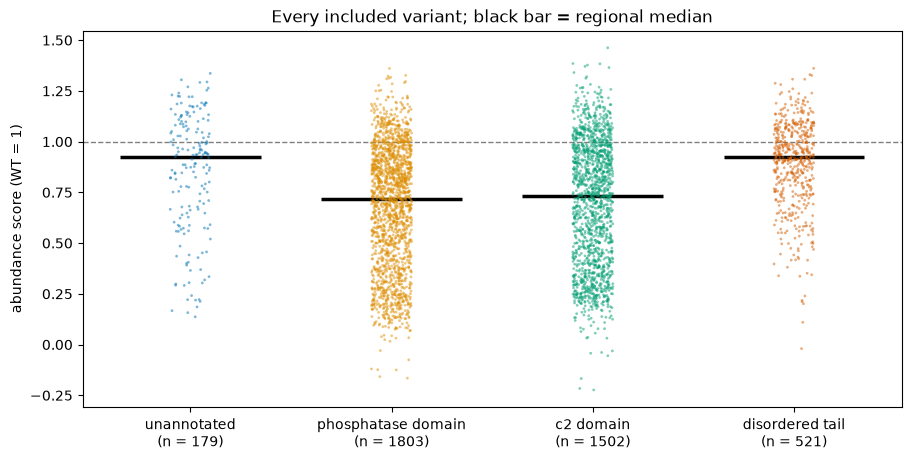

In [8]:
# Individual scores next to the regional medians
region_colors = dict(zip(region_order, sns.color_palette("colorblind", len(region_order))))   # one color per region, reused below
n_by_region = included.groupby("region").size()
labels = [f"{r.replace('_', ' ')}\n(n = {n_by_region[r]})" for r in region_order]

fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
sns.stripplot(data=included, x="region", y="score", order=region_order, hue="region", palette=region_colors,
              size=2, alpha=0.5, legend=False, ax=ax)
for i, r in enumerate(region_order):
    ax.hlines(summary.loc[r, "variant_median"], i - 0.35, i + 0.35, color="black", lw=2.5)   # regional median
ax.axhline(1, ls="--", color="gray", lw=1)
ax.set_xticks(range(len(region_order)), labels)
ax.set(xlabel="", ylabel="abundance score (WT = 1)", title="Every included variant; black bar = regional median")
plt.show()

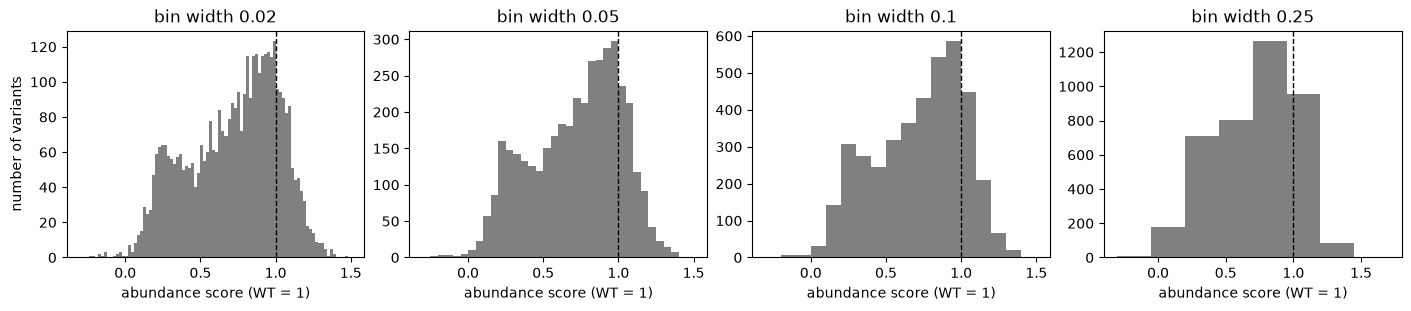

In [ ]:
# Histograms: vary the bin width
assert included["score"].between(-0.3, 1.5).all()   # the fixed range below shows every variant

fig, axes = plt.subplots(1, 4, figsize=(14, 3), layout="constrained")
for ax, width in zip(axes, [0.02, 0.05, 0.1, 0.25]): #vkc - why do the far borders need to vary like this? stupid machine
    bins = np.arange(-0.3, 1.5 + width, width)   # same first edge, different width
    ax.hist(included["score"], bins=bins, color="gray")
    ax.axvline(1, ls="--", color="black", lw=1)
    ax.set(title=f"bin width {width}", xlabel="abundance score (WT = 1)")
axes[0].set_ylabel("number of variants")
plt.show()

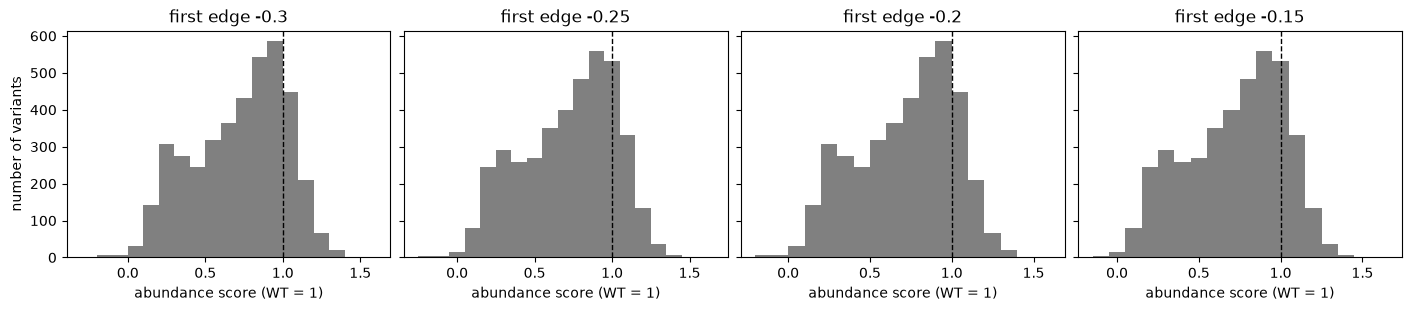

In [10]:
# Histograms: same bin width, different starting edge
width = 0.1

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True, layout="constrained")
for ax, start in zip(axes, [-0.30, -0.25, -0.20, -0.15]):
    bins = np.arange(start, 1.6 + width, width)
    ax.hist(included["score"], bins=bins, color="gray")
    ax.axvline(1, ls="--", color="black", lw=1)
    ax.set(title=f"first edge {start}", xlabel="abundance score (WT = 1)")
axes[0].set_ylabel("number of variants")
plt.show()

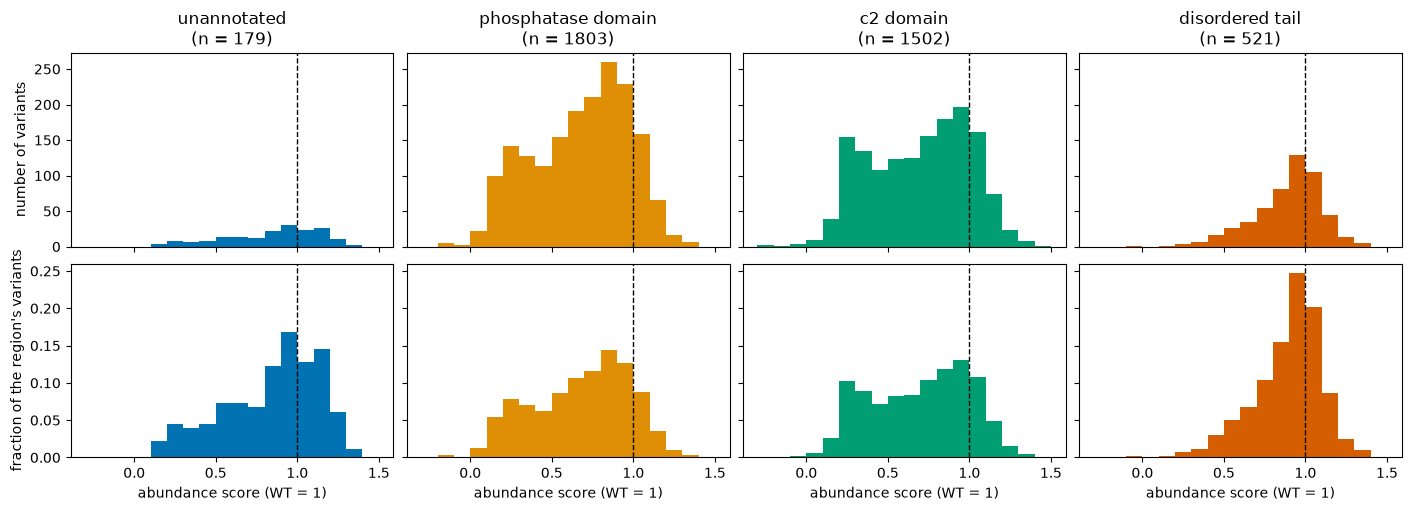

In [11]:
# Histograms by region: counts versus proportions, with shared bins
bins = np.arange(-0.3, 1.5 + 0.1, 0.1)   # one set of bins for every panel

fig, axes = plt.subplots(2, len(region_order), figsize=(14, 5), sharex=True, sharey="row", layout="constrained")
for j, r in enumerate(region_order):
    s = included.loc[included["region"] == r, "score"]
    axes[0, j].hist(s, bins=bins, color=region_colors[r])
    axes[1, j].hist(s, bins=bins, weights=np.ones(len(s)) / len(s), color=region_colors[r])   # each bar = fraction of this region
    axes[0, j].set_title(f"{r.replace('_', ' ')}\n(n = {len(s)})")
    axes[1, j].set_xlabel("abundance score (WT = 1)")
    for ax in axes[:, j]:
        ax.axvline(1, ls="--", color="black", lw=1)
axes[0, 0].set_ylabel("number of variants")
axes[1, 0].set_ylabel("fraction of the region's variants")
plt.show()

region
phosphatase_domain    1803
c2_domain             1502
disordered_tail        521
unannotated            179
Name: count, dtype: int64


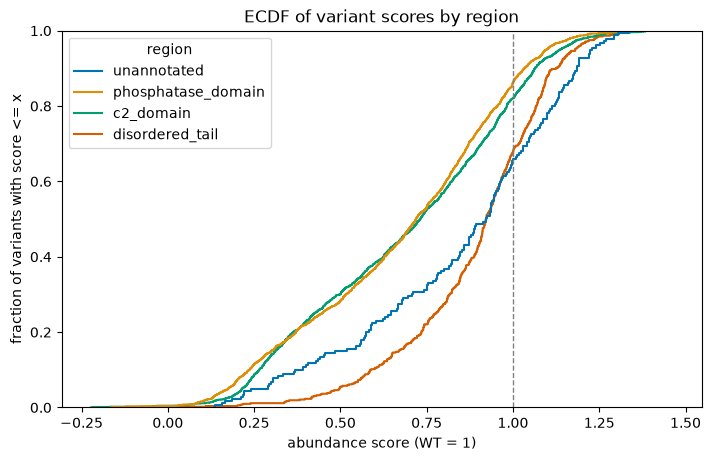

In [12]:
# ECDF by region (no bins to choose)
print(included["region"].value_counts())   # sample size behind each curve

fig, ax = plt.subplots(figsize=(7, 4.5), layout="constrained")
sns.ecdfplot(data=included, x="score", hue="region", hue_order=region_order, palette=region_colors, ax=ax)
ax.axvline(1, ls="--", color="gray", lw=1)   # WT
ax.set(xlabel="abundance score (WT = 1)", ylabel="fraction of variants with score <= x",
       title="ECDF of variant scores by region")
plt.show()

**Figure checklist** (from the Session 4 slides)
- Are the labels descriptive and legible, with units where relevant?
- Is the WT reference (score = 1) visible or explained? What is "high" and what is "low"?
- Does `figsize` match the size the figure will be shown at?
- Do color and shape mean the same thing in every panel and figure?
- Is the palette right for the data: distinct colors for unordered groups, sequential for ordered amounts, diverging only around a meaningful center?
- Are colorbars labeled with visible scale marks? Do gridlines stay quiet?

**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## 4. Color across related plots

When color conveys information across related plots, use a single scale and reference for consistency: the same color limits, the same center (WT = 1), and the same palette meaning in every panel.

Prompts:
- Make two related plots that use color for the abundance score. Do they share color limits? What goes wrong if they do not?

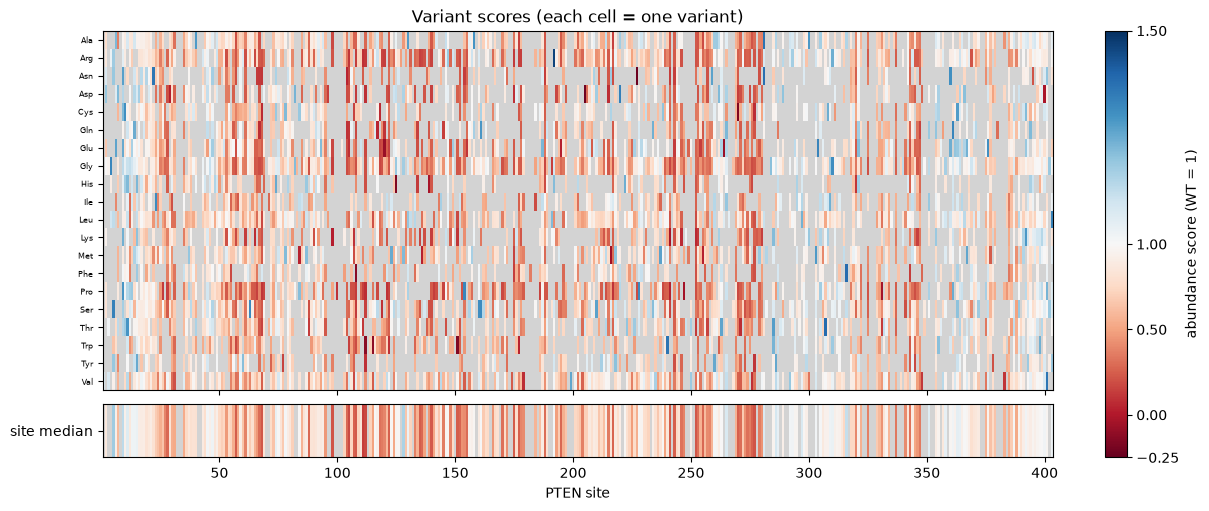

variant scores range -0.22 to 1.46
site medians range   0.13 to 1.18


In [ ]:
# Related plots with shared color limits and one reference (WT = 1)
from matplotlib.colors import TwoSlopeNorm

norm = TwoSlopeNorm(vmin=-0.25, vcenter=1, vmax=1.5)   # one set of limits, centered on WT
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgrey")   # missing = grey, which is not a score color

mutants = sorted(letter)
variant_grid = missense.pivot(index="mut", columns="pos", values="score").reindex(index=mutants, columns=range(1, n_sites + 1))
site_row = site_stats(missense, n_sites, minimum_variants)["median"].to_frame().T   # one row, one column per site

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, gridspec_kw={"height_ratios": [10, 1.5]}, layout="constrained")
im = axes[0].imshow(variant_grid.to_numpy(), aspect="auto", cmap=cmap, norm=norm, interpolation="nearest",
                    extent=(0.5, n_sites + 0.5, len(mutants) - 0.5, -0.5))
axes[0].set(yticks=range(len(mutants)), yticklabels=mutants, title="Variant scores (each cell = one variant)")
axes[0].tick_params(axis="y", labelsize=6)
axes[1].imshow(site_row.to_numpy(), aspect="auto", cmap=cmap, norm=norm, interpolation="nearest",
               extent=(0.5, n_sites + 0.5, 0.5, -0.5))
axes[1].set(yticks=[0], yticklabels=["site median"], xlabel="PTEN site")
fig.colorbar(im, ax=axes, label="abundance score (WT = 1)", ticks=[-0.25, 0, 0.5, 1, 1.5])
plt.show()

# What goes wrong without shared limits: each panel's own range would be stretched to its own colors
print("variant scores range", round(np.nanmin(variant_grid.to_numpy()), 2), "to", round(np.nanmax(variant_grid.to_numpy()), 2))
print("site medians range  ", round(np.nanmin(site_row.to_numpy()), 2), "to", round(np.nanmax(site_row.to_numpy()), 2))

In [28]:
site_row

pos,1,2,3,4,5,6,7,8,9,10,...,394,395,396,397,398,399,400,401,402,403
median,NaN,0.87283,NaN,NaN,1.17585,0.922252,0.595662,NaN,1.132554,0.936728,...,0.908201,0.962237,0.92741,0.969073,0.986578,0.993964,1.015925,0.963241,NaN,1.02659


**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## 5. Sensitivity shown across sites

Comparing sites shows that most sites have consistent results under different filtering criteria, but not all. The slides' example filters PTEN data to require `expts >= 6`: 242 positions remain eligible, and 75 lose eligibility.

Prompts:
- Which sites stay eligible under the stricter filter, and which are lost? Where along the sequence are the lost sites?
- For the sites that stay, how much does each site's median score change? Match sites by position, not by row order.
- A site that loses eligibility has *no* new median, which is different from a change of zero.

In [14]:
# Site medians: baseline versus expts >= 6, matched by position
_, _, site_table_strict = region_summary(missense, site_region, minimum_variants, 6)

baseline = site_table[["median", "region"]].rename_axis("pos").reset_index()
strict = site_table_strict[["median"]].rename_axis("pos").reset_index()
compare = pd.merge(baseline, strict, on="pos", how="outer", suffixes=("_baseline", "_strict"),
                   indicator=True, validate="one_to_one")
compare["change"] = compare["median_strict"] - compare["median_baseline"]   # NaN for lost sites, not 0

print(compare["_merge"].value_counts())
assert (compare["_merge"] != "right_only").all()   # a stricter filter cannot add sites
assert (compare["_merge"] == "both").sum() == 242 and (compare["_merge"] == "left_only").sum() == 75   # the slide's numbers

lost = compare[compare["_merge"] == "left_only"]
print("\nlost sites by region:")
print(lost["region"].value_counts())
print("\nchange in median for the sites that stay:")
print(compare["change"].describe())

_merge
both          242
left_only      75
right_only      0
Name: count, dtype: int64

lost sites by region:
region
phosphatase_domain    31
c2_domain             28
disordered_tail       11
unannotated            5
Name: count, dtype: int64

change in median for the sites that stay:
count    242.000000
mean      -0.003939
std        0.051603
min       -0.169042
25%       -0.023585
50%       -0.003200
75%        0.013649
max        0.337064
Name: change, dtype: float64


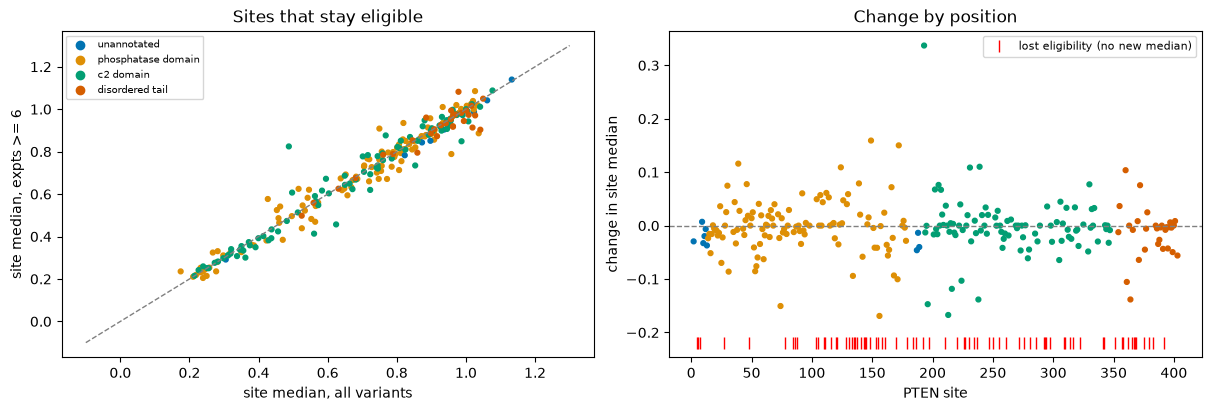

In [15]:
# Plot the comparison across sites
kept = compare[compare["_merge"] == "both"]
kept_colors = kept["region"].map(region_colors).tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")

axes[0].scatter(kept["median_baseline"], kept["median_strict"], c=kept_colors, s=12)
axes[0].plot([-0.1, 1.3], [-0.1, 1.3], ls="--", color="gray", lw=1)   # no change
axes[0].set(xlabel="site median, all variants", ylabel="site median, expts >= 6", title="Sites that stay eligible")
for r in region_order:
    axes[0].scatter([], [], color=region_colors[r], label=r.replace("_", " "))
axes[0].legend(fontsize=7)

axes[1].scatter(kept["pos"], kept["change"], c=kept_colors, s=12)
axes[1].axhline(0, ls="--", color="gray", lw=1)
axes[1].plot(lost["pos"], [kept["change"].min() - 0.05] * len(lost), "|", color="red", ms=8, label="lost eligibility (no new median)")
axes[1].set(xlabel="PTEN site", ylabel="change in site median", title="Change by position")
axes[1].legend(loc="upper right", fontsize=8)
plt.show()

**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## 6. Choosing an extension and preparing the presentation

Your team will define and investigate one question that extends the PTEN analyses done so far. Next class, each team presents:
- a definition of the question
- how you approached it, including **at least one explicit code example with an accompanying explanation**
- a brief summary of your results and conclusions
- plan for **5 to 7 minutes** plus brief questions. Slides and the whiteboard are both fine, and the whiteboard is encouraged for describing the problem and approach.

**Prediction sheet:**
- Define the question or goal:
- How will you approach it? Does this require new data or new analysis?
- What are your anticipated results?
- How will you ensure that your analysis is correct?

In [ ]:
# Working space for the extension

**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## Reproducibility record

Run this last, after restarting the kernel and running all cells.

In [ ]:
import session_info
session_info.show(dependencies=True)